# Modeling & SHAP ablation (RQ1)

Needs `features.parquet` and `feature_groups.json`.

In [6]:
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/Social_Media_Mining_Project'
OUT_DIR = f'{BASE}/outputs/'
FIG_DIR = f'{BASE}/figures/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!pip install shap -q

In [8]:
import os, random, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, f1_score, accuracy_score,
                              roc_auc_score, classification_report)

def set_all_seeds(seed=6):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_all_seeds(6)

In [9]:
df = pd.read_parquet(f'{OUT_DIR}features.parquet')
with open(f'{OUT_DIR}feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

print('Loaded:', df.shape)
print('Feature groups:')
for g, cols in FEATURE_GROUPS.items():
    print(f'  {g}: {len(cols)} features')

Loaded: (49238, 102)
Feature groups:
  text_lexical: 11 features
  text_semantic: 50 features
  structural: 16 features


## Train/test split

Stratified by subreddit so every community appears in both train and test.

In [10]:
y_reg = df['engagement_score'].values
y_cls = df['is_viral'].values

ALL_FEATURES = (
    FEATURE_GROUPS['text_lexical'] +
    FEATURE_GROUPS['text_semantic'] +
    FEATURE_GROUPS['structural']
)

X = df[ALL_FEATURES].fillna(0).values

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=6,
    stratify=df['subreddit'].values
)

print(f'Train: {len(train_idx):,}  Test: {len(test_idx):,}')
print(f'Viral rate — train: {y_cls[train_idx].mean():.3f}  test: {y_cls[test_idx].mean():.3f}')

Train: 39,390  Test: 9,848
Viral rate — train: 0.201  test: 0.197


## Ablation study

In [11]:
CONFIGS = {
    'text_only':       FEATURE_GROUPS['text_lexical'] + FEATURE_GROUPS['text_semantic'],
    'structural_only': FEATURE_GROUPS['structural'],
    'combined':        ALL_FEATURES,
}

XGB_PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=6, n_jobs=-1, verbosity=0
)

results = {}

for config_name, feat_cols in CONFIGS.items():
    print(f'\n--- {config_name} ({len(feat_cols)} features) ---')
    X_cfg = df[feat_cols].fillna(0).values
    X_tr, X_te = X_cfg[train_idx], X_cfg[test_idx]
    y_tr_reg, y_te_reg = y_reg[train_idx], y_reg[test_idx]
    y_tr_cls, y_te_cls = y_cls[train_idx], y_cls[test_idx]

    reg = XGBRegressor(**XGB_PARAMS)
    reg.fit(X_tr, y_tr_reg)
    y_pred_reg = reg.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred_reg))
    mae  = mean_absolute_error(y_te_reg, y_pred_reg)
    r2   = r2_score(y_te_reg, y_pred_reg)
    print(f'  Regression  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}')

    clf = XGBClassifier(**XGB_PARAMS, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_tr, y_tr_cls)
    y_pred_cls = clf.predict(X_te)
    y_prob_cls = clf.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te_cls, y_pred_cls)
    f1  = f1_score(y_te_cls, y_pred_cls)
    auc = roc_auc_score(y_te_cls, y_prob_cls)
    print(f'  Classification  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

    results[config_name] = dict(
        reg_model=reg, clf_model=clf, feat_cols=feat_cols,
        rmse=rmse, mae=mae, r2=r2, acc=acc, f1=f1, auc=auc
    )


--- text_only (61 features) ---
  Regression  RMSE=0.0907  MAE=0.0702  R2=0.4473
  Classification  Acc=0.8210  F1=0.2760  AUC=0.8024

--- structural_only (16 features) ---
  Regression  RMSE=0.0455  MAE=0.0338  R2=0.8607
  Classification  Acc=0.8991  F1=0.7392  AUC=0.9482

--- combined (77 features) ---
  Regression  RMSE=0.0441  MAE=0.0328  R2=0.8695
  Classification  Acc=0.9071  F1=0.7529  AUC=0.9526



=== ABLATION RESULTS (RQ1) ===
                 n_features    RMSE     MAE      R2     Acc      F1     AUC
text_only              61.0  0.0907  0.0702  0.4473  0.8210  0.2760  0.8024
structural_only        16.0  0.0455  0.0338  0.8607  0.8991  0.7392  0.9482
combined               77.0  0.0441  0.0328  0.8695  0.9071  0.7529  0.9526


/tmp/ipykernel_3419/2351123507.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15)
/tmp/ipykernel_3419/2351123507.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15)
/tmp/ipykernel_3419/2351123507.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15)


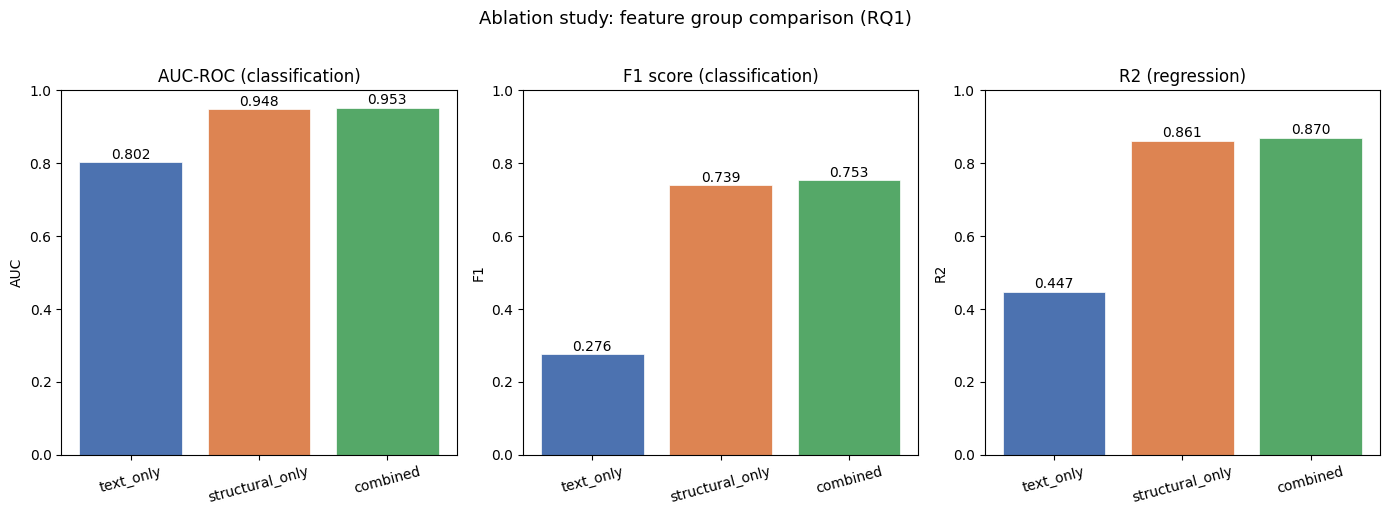

In [12]:
summary = pd.DataFrame({
    cfg: {
        'n_features': len(v['feat_cols']),
        'RMSE':  round(v['rmse'], 4),
        'MAE':   round(v['mae'], 4),
        'R2':    round(v['r2'], 4),
        'Acc':   round(v['acc'], 4),
        'F1':    round(v['f1'], 4),
        'AUC':   round(v['auc'], 4),
    }
    for cfg, v in results.items()
}).T

print('\n=== ABLATION RESULTS (RQ1) ===')
print(summary.to_string())
summary.to_csv(f'{OUT_DIR}ablation_results.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [('AUC','AUC-ROC (classification)'),
           ('F1','F1 score (classification)'),
           ('R2','R2 (regression)')]
colors = ['#4C72B0','#DD8452','#55A868']
for ax, (metric, title) in zip(axes, metrics):
    vals = summary[metric].astype(float)
    ax.bar(vals.index, vals.values, color=colors, edgecolor='white', lw=0.5)
    ax.set_title(title); ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
    ax.set_xticklabels(vals.index, rotation=15)

plt.suptitle('Ablation study: feature group comparison (RQ1)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}04_ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP explanation

In [13]:
combined_model  = results['combined']['reg_model']
feat_cols       = results['combined']['feat_cols']
X_test_combined = df[feat_cols].fillna(0).values[test_idx]
feat_names      = feat_cols

explainer   = shap.TreeExplainer(combined_model)
shap_values = explainer.shap_values(X_test_combined)
print('SHAP values shape:', shap_values.shape)

SHAP values shape: (9848, 77)


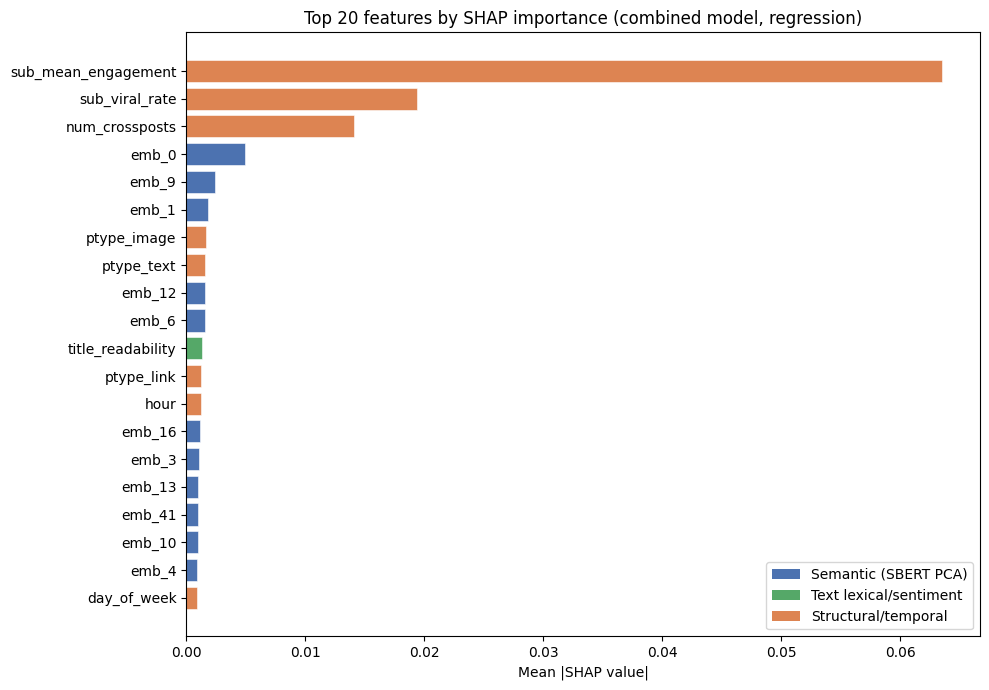

Saved SHAP top 20 -> /content/drive/MyDrive/Social_Media_Mining_Project/outputs/rq1_shap_top20.csv

--- Feature group contribution (mean |SHAP|) ---
  text_lexical        : 0.004940
  text_semantic       : 0.035965
  structural          : 0.105723


In [14]:
shap_df = pd.DataFrame(
    np.abs(shap_values).mean(axis=0),
    index=feat_names,
    columns=['mean_abs_shap']
).sort_values('mean_abs_shap', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top20 = shap_df.head(20)

def get_color(fname):
    if fname in FEATURE_GROUPS['text_semantic']:  return '#4C72B0'
    elif fname in FEATURE_GROUPS['text_lexical']: return '#55A868'
    else:                                         return '#DD8452'

bar_colors = [get_color(f) for f in top20.index]
ax.barh(top20.index[::-1], top20['mean_abs_shap'][::-1],
        color=bar_colors[::-1], edgecolor='white', lw=0.4)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 20 features by SHAP importance (combined model, regression)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Semantic (SBERT PCA)'),
    Patch(facecolor='#55A868', label='Text lexical/sentiment'),
    Patch(facecolor='#DD8452', label='Structural/temporal'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}04_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# save top20 csv (from NB06)
shap_df.head(20).to_csv(f'{OUT_DIR}rq1_shap_top20.csv', index=True)
print(f'Saved SHAP top 20 -> {OUT_DIR}rq1_shap_top20.csv')

print('\n--- Feature group contribution (mean |SHAP|) ---')
for grp, cols in FEATURE_GROUPS.items():
    group_shap = shap_df.loc[shap_df.index.isin(cols), 'mean_abs_shap'].sum()
    print(f'  {grp:<20}: {group_shap:.6f}')

/tmp/ipykernel_3419/3562679353.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, max_display=20, show=False)


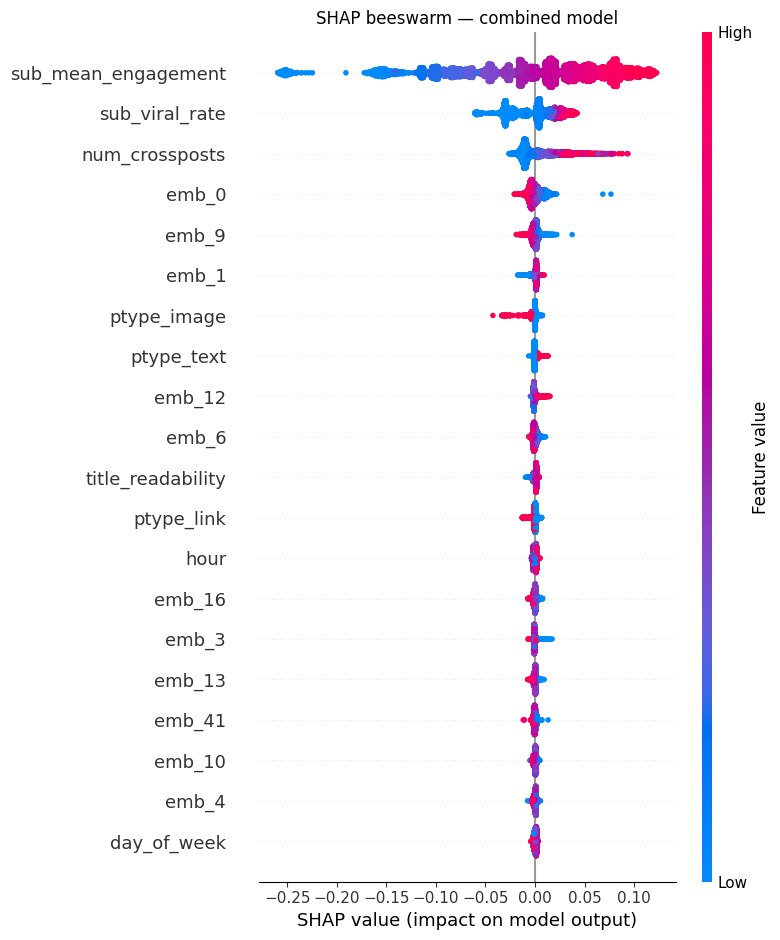

In [15]:
X_test_df = pd.DataFrame(X_test_combined, columns=feat_names)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_df, max_display=20, show=False)
plt.title('SHAP beeswarm — combined model')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}04_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
combined_clf = results['combined']['clf_model']
X_te_full    = df[results['combined']['feat_cols']].fillna(0).values[test_idx]
y_te_pred    = combined_clf.predict(X_te_full)
print('=== Classification Report (combined model) ===')
print(classification_report(y_cls[test_idx], y_te_pred, target_names=['Non-viral','Viral']))

=== Classification Report (combined model) ===
              precision    recall  f1-score   support

   Non-viral       0.93      0.95      0.94      7905
       Viral       0.79      0.72      0.75      1943

    accuracy                           0.91      9848
   macro avg       0.86      0.84      0.85      9848
weighted avg       0.90      0.91      0.91      9848



## IV regression (crosspost -> engagement causality)

IV sample: 48,253 posts

Instrument relevance: Spearman rho(hour, num_crossposts) = -0.0421  p=2.1242e-20
  Weak instrument — interpret with caution

OLS coefficient on num_crossposts (standardized): beta_OLS = 0.010934

Stage 1 R² = 0.2847  |  F-statistic = 19200.22
  Strong instrument (F > 10)

2SLS coefficient on num_crossposts (standardized): beta_2SLS = 0.102220

beta_OLS=0.010934  beta_2SLS=0.102220  ratio=9.3489

95% Bootstrap CI for beta_2SLS: [-0.740282, 0.643419]
  Not significant (CI crosses zero)


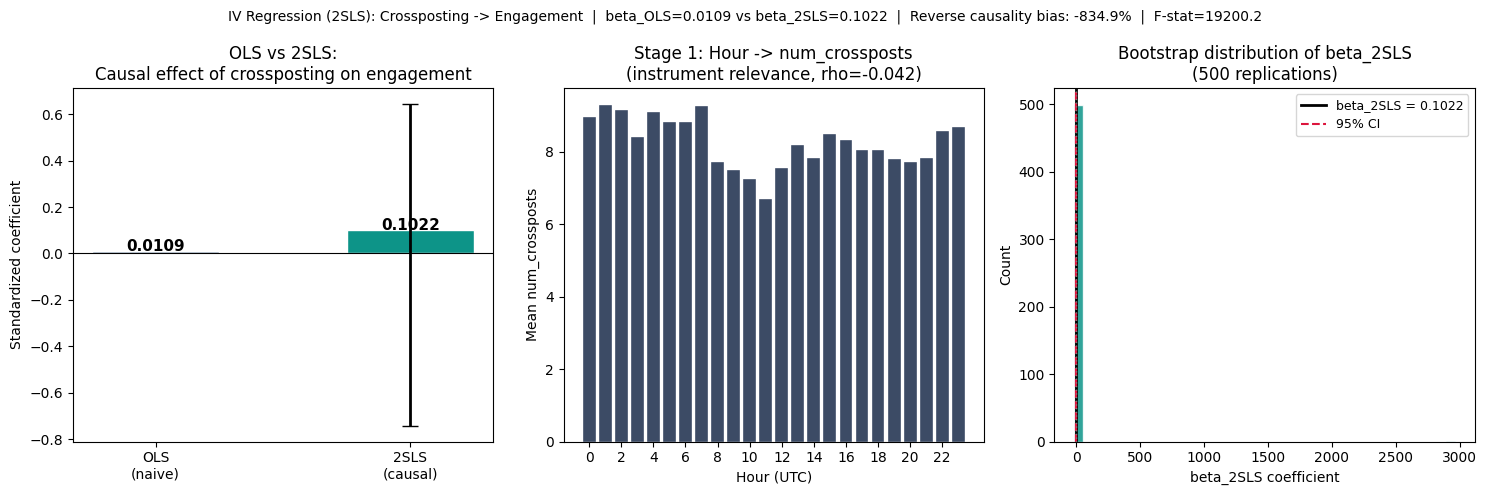

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

controls   = ['ptype_image', 'ptype_text', 'ptype_video',
              'is_external_link', 'has_body_text',
              'sub_mean_engagement', 'sub_viral_rate',
              'is_weekend', 'month']
instrument = 'hour'
treatment  = 'num_crossposts'
outcome    = 'engagement_score'

cols_needed = [instrument, treatment, outcome] + controls
df_iv = df[cols_needed].dropna().copy()
print(f"IV sample: {len(df_iv):,} posts")

rho_iv, p_iv = spearmanr(df_iv[instrument], df_iv[treatment])
print(f"\nInstrument relevance: Spearman rho(hour, num_crossposts) = {rho_iv:.4f}  p={p_iv:.4e}")
print(f"  {'Instrument is relevant' if abs(rho_iv) > 0.05 and p_iv < 0.05 else 'Weak instrument — interpret with caution'}")

X_ols        = df_iv[[treatment] + controls].values
y            = df_iv[outcome].values
scaler       = StandardScaler()
X_ols_scaled = scaler.fit_transform(X_ols)
ols          = LinearRegression().fit(X_ols_scaled, y)
beta_ols     = ols.coef_[0]
print(f"\nOLS coefficient on num_crossposts (standardized): beta_OLS = {beta_ols:.6f}")

X_stage1        = df_iv[[instrument] + controls].values
X_stage1_scaled = StandardScaler().fit_transform(X_stage1)
stage1          = LinearRegression().fit(X_stage1_scaled, df_iv[treatment].values)
crossposts_hat  = stage1.predict(X_stage1_scaled)

y1        = df_iv[treatment].values
ss_res    = np.sum((y1 - crossposts_hat)**2)
ss_tot    = np.sum((y1 - y1.mean())**2)
r2_stage1 = 1 - ss_res/ss_tot
n, k      = len(y1), X_stage1_scaled.shape[1]
f_stat    = (r2_stage1 / 1) / ((1 - r2_stage1) / (n - k - 1))
print(f"\nStage 1 R² = {r2_stage1:.4f}  |  F-statistic = {f_stat:.2f}")
print(f"  {'Strong instrument (F > 10)' if f_stat > 10 else 'Weak instrument (F < 10)'}")

X_stage2        = np.column_stack([crossposts_hat, df_iv[controls].values])
X_stage2_scaled = StandardScaler().fit_transform(X_stage2)
stage2          = LinearRegression().fit(X_stage2_scaled, y)
beta_2sls       = stage2.coef_[0]
print(f"\n2SLS coefficient on num_crossposts (standardized): beta_2SLS = {beta_2sls:.6f}")

ratio    = beta_2sls / beta_ols if beta_ols != 0 else float('inf')
bias_pct = (1 - ratio) * 100
print(f"\nbeta_OLS={beta_ols:.6f}  beta_2SLS={beta_2sls:.6f}  ratio={ratio:.4f}")

np.random.seed(6)
boot_coefs = []
idx = np.arange(len(df_iv))
for _ in range(500):
    b_idx  = np.random.choice(idx, size=len(idx), replace=True)
    df_b   = df_iv.iloc[b_idx]
    X1b    = StandardScaler().fit_transform(df_b[[instrument] + controls].values)
    chat   = LinearRegression().fit(X1b, df_b[treatment].values).predict(X1b)
    X2b    = StandardScaler().fit_transform(np.column_stack([chat, df_b[controls].values]))
    boot_coefs.append(LinearRegression().fit(X2b, df_b[outcome].values).coef_[0])

ci_low, ci_high = np.percentile(boot_coefs, [2.5, 97.5])
print(f"\n95% Bootstrap CI for beta_2SLS: [{ci_low:.6f}, {ci_high:.6f}]")
print(f"  {'Significant' if ci_low > 0 or ci_high < 0 else 'Not significant'} (CI {'does not cross' if ci_low > 0 or ci_high < 0 else 'crosses'} zero)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

labels = ['OLS\n(naive)', '2SLS\n(causal)']
values = [beta_ols, beta_2sls]
bars   = axes[0].bar(labels, values, color=['#94A3B8','#0D9488'], edgecolor='white', width=0.5)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].errorbar(['2SLS\n(causal)'], [beta_2sls],
                 yerr=[[beta_2sls - ci_low], [ci_high - beta_2sls]],
                 fmt='none', color='black', capsize=6, lw=2)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.0005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('OLS vs 2SLS:\nCausal effect of crossposting on engagement')
axes[0].set_ylabel('Standardized coefficient')

hour_means = df_iv.groupby(instrument)[treatment].mean()
axes[1].bar(hour_means.index, hour_means.values,
            color='#1A2B4A', edgecolor='white', lw=0.3, alpha=0.85)
axes[1].set_title(f'Stage 1: Hour -> num_crossposts\n(instrument relevance, rho={rho_iv:.3f})')
axes[1].set_xlabel('Hour (UTC)'); axes[1].set_ylabel('Mean num_crossposts')
axes[1].set_xticks(range(0, 24, 2))

axes[2].hist(boot_coefs, bins=40, color='#0D9488', edgecolor='white', lw=0.3, alpha=0.85)
axes[2].axvline(beta_2sls, color='black', lw=2, label=f'beta_2SLS = {beta_2sls:.4f}')
axes[2].axvline(ci_low,    color='crimson', lw=1.5, linestyle='--', label='95% CI')
axes[2].axvline(ci_high,   color='crimson', lw=1.5, linestyle='--')
axes[2].axvline(0,         color='gray', lw=1, linestyle=':')
axes[2].set_title('Bootstrap distribution of beta_2SLS\n(500 replications)')
axes[2].set_xlabel('beta_2SLS coefficient'); axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

plt.suptitle(
    f'IV Regression (2SLS): Crossposting -> Engagement  |  '
    f'beta_OLS={beta_ols:.4f} vs beta_2SLS={beta_2sls:.4f}  |  '
    f'Reverse causality bias: {bias_pct:.1f}%  |  F-stat={f_stat:.1f}',
    fontsize=10
)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}04_iv_regression_2sls.png', dpi=150, bbox_inches='tight')
plt.show()